# Complete SVM Pipeline (from scratch)

## Step 1: Loads CIFAR-10 Dataset

In [1]:
#imports modules
import numpy as np
import matplotlib.pyplot as plt
import scipy
np.random.seed(42)

In [2]:
#function to extract images from CIFAR-10 readme
def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

In [3]:
#function to extract images from CIFAR-10 readme - extracts only data and labels in x,y format
my_keys = [b'data',b'labels']
def unpickle_mod(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
        dict = {key:dict[key] for key in my_keys}
    return dict

In [4]:
#reads and 'unfolds' data from CIFAR-10 using helper function above - only x and y components
base_dir = r"/home/disk_2/Coding/CS231N/datasets/CIFAR10/cifar-10-python/cifar-10-batches-py/"
b1_mod = unpickle_mod(base_dir + r"data_batch_1") 
b2_mod = unpickle_mod(base_dir + r"data_batch_2")
b3_mod = unpickle_mod(base_dir + r"data_batch_3")
b4_mod = unpickle_mod(base_dir + r"data_batch_4")
b5_mod = unpickle_mod(base_dir + r"data_batch_5")
test_mod = unpickle_mod(base_dir + r"test_batch")

In [5]:
#reads english labels corresponding to numeric labels
eng_labels = unpickle(base_dir + r"batches.meta") 

#creates mapping for labels from numbers to english labels
label_map = dict(zip(range(10),eng_labels[b'label_names']))
label_map

{0: b'airplane',
 1: b'automobile',
 2: b'bird',
 3: b'cat',
 4: b'deer',
 5: b'dog',
 6: b'frog',
 7: b'horse',
 8: b'ship',
 9: b'truck'}

In [12]:
b1_mod[b'data'].shape

(10000, 3072)

In [13]:
#Note for self:Each batch of CIFAR-10 data contains 10K samples with 32x32 pixels x 3 channels = 3072. So each row in matrix is one image

## Step 2: Visualizing the dataset

b'deer'


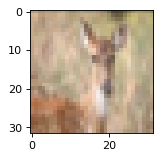

In [16]:
#set index to pull out an image
idx = 4000

#pull out image and label 
ex = b2_mod[b'data'][idx]
ex_label = b2_mod[b'labels'][idx]

#resize image from CIFAR10 data into 3-D numpy array -- note here that numpy follows (depth, rows, columns) nomenclature
ex_new = np.reshape(ex, (3,32,32))

#prints label and the image
print(label_map[ex_label])
plt.figure(figsize = (2,2), dpi = 80)
plt.imshow(ex_new.transpose(1, 2, 0))
plt.show()

## Step 3: Writing an SVM Classifier

### Step 3.1: Data Normalization

In [17]:
#running pre-processing in batches
def normalize_data(batch):
    batch_train = batch[b'data']
    batch_train_mean = batch_train.mean(axis=1).reshape(batch_train.shape[0],1)
    # print(batch_train_mean.shape)
    batch_train_var = batch_train.var(axis=1).reshape(batch_train.shape[0],1)
    # print(batch_train_var.shape)
    batch_train_x = (batch_train - batch_train_mean)/np.sqrt(batch_train_var)
    print(batch_train_x.shape)
    print(np.round(batch_train_x.mean(axis = 1).max(),2))
    print(np.round(batch_train_x.var(axis = 1).min(),2))
    print(np.round(batch_train_x.var(axis = 1).max(),2))
    return batch_train_x, batch_train_mean, batch_train_var

In [18]:
b1_mod_train_x = normalize_data(b1_mod)[0]
b2_mod_train_x = normalize_data(b2_mod)[0]
b3_mod_train_x = normalize_data(b3_mod)[0]
b4_mod_train_x = normalize_data(b4_mod)[0]
b5_mod_train_x = normalize_data(b5_mod)[0]
test_mod_x = normalize_data(test_mod)[0]

(10000, 3072)
0.0
1.0
1.0
(10000, 3072)
0.0
1.0
1.0
(10000, 3072)
0.0
1.0
1.0
(10000, 3072)
0.0
1.0
1.0
(10000, 3072)
0.0
1.0
1.0
(10000, 3072)
0.0
1.0
1.0


In [19]:
b1_mod_train_y = np.array(b1_mod[b'labels'], dtype = np.int8)
b2_mod_train_y = np.array(b2_mod[b'labels'], dtype = np.int8)
b3_mod_train_y = np.array(b3_mod[b'labels'], dtype = np.int8)
b4_mod_train_y = np.array(b4_mod[b'labels'], dtype = np.int8)
b5_mod_train_y = np.array(b5_mod[b'labels'], dtype = np.int8)
test_mod_y = np.array(test_mod[b'labels'], dtype = np.int8)

In [20]:
#memory mgt
del b1_mod,b2_mod,b3_mod,b4_mod,b5_mod

In [21]:
#qc
print(b1_mod_train_y.shape)
print(b1_mod_train_y.dtype)
print(test_mod_y.shape)
print(test_mod_y.dtype)

(10000,)
int8
(10000,)
int8


### Step 3.2 Writes an SVM Classifier

In [176]:
class SVM(object):

    def __init__(self):
        pass

    def train(self, x, y, num_classes = 10, reg_lambda = 0.5):
        #bias trick, add a column of ones in x_train matrix so that algo is only concerned about optimizing over W (weight matrix)
        ones_col = np.ones((x.shape[0],1))
        self.x_train = np.hstack((ones_col,x))      
        self.y_train = y

        #initializes weights with small random values to generate unoptimized output scores
        self.W = (np.random.rand(self.x_train.shape[1], num_classes)) * 0.001
        self.y_pred = self.x_train @ self.W

        #computes and prints loss
        #step1 : get the output score of the correct class
        x_comp = np.arange(len(self.y_train))
        y_comp = self.y_train
        scr_correct_class = self.y_pred[x_comp, y_comp].reshape(-1,1)

        #step2 : get the max of 0, difference in scores plus buffer
        #self.y_pred is scores of SVM over all classes for each instance in training set
        vector_loss = np.maximum(np.zeros(self.y_pred.shape),(self.y_pred - scr_correct_class + 1))
        vector_loss[np.arange(len(self.y_train)), self.y_train] = 0
        
        #step 3 : sum across all categories for each instance 
        #here, we also need to subtract 10,000 1's from loss since for each image, we have added a one for each correctly specified image
        #finally we take an average over all training examples
        #lastly, add regularization parameter - L2 reg
        L = (vector_loss.sum() / self.x_train.shape[0])
        R = (reg_lambda * (self.W**2).sum())
        fin_loss = L + R

        return fin_loss

    def optimize(self, num_iters=2, learning_rate = 0.01):
        #optimization - stochastic gradient descent
        #change W by a small amount and check the direction of change of loss
        self.W += 0.001
        
    

In [175]:
SVM_RK = SVM()
SVM_RK.train(x=b1_mod_train_x,y=b1_mod_train_y)

np.float64(9.029405520692983)

### Step 3.3 Defines an accuracy class

In [12]:
#accuracy function
class accuracy(object):
    
    def __init__(self):
        pass
        
    def calculate(self, y_pred, y_true):
        self.y_pred = y_pred
        self.y_true = y_true
        #counts same labels, divides it by total size of array
        self.acc = np.count_nonzero((np.abs(y_pred-y_true))==0)/np.size(self.y_true)
        return float(self.acc)
    